# Preparation

## Import Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score , confusion_matrix, classification_report

## Import Dataset

In [2]:
Fake_df=pd.read_csv('./Dataset/FakeNewsNet.csv')
Fake_df.head()

,title,news_url,source_domain,tweet_num,real
0,Kandi Burruss Explodes Over Rape Accusation on...,http://toofab.com/2017/05/08/real-housewives-a...,toofab.com,42,1
1,People's Choice Awards 2018: The best red carp...,https://www.today.com/style/see-people-s-choic...,www.today.com,0,1
2,Sophia Bush Sends Sweet Birthday Message to 'O...,https://www.etonline.com/news/220806_sophia_bu...,www.etonline.com,63,1
3,Colombian singer Maluma sparks rumours of inap...,https://www.dailymail.co.uk/news/article-33655...,www.dailymail.co.uk,20,1
4,Gossip Girl 10 Years Later: How Upper East Sid...,https://www.zerchoo.com/entertainment/gossip-g...,www.zerchoo.com,38,1


## Data Understanding

In [3]:
Fake_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23196 entries, 0 to 23195
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   title          23196 non-null  object
 1   news_url       22866 non-null  object
 2   source_domain  22866 non-null  object
 3   tweet_num      23196 non-null  int64 
 4   real           23196 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 906.2+ KB


In [4]:
Fake_df.isna().sum()

title              0
news_url         330
source_domain    330
tweet_num          0
real               0
dtype: int64

In [5]:
sum_duplicate=Fake_df.duplicated().sum()
print(f"Number of duplicate rows: {sum_duplicate}")

Number of duplicate rows: 137


In [6]:
row, column =Fake_df.shape
print("Number of Rows:", row)
print("Number of Columns:", column)

Number of Rows: 23196
Number of Columns: 5


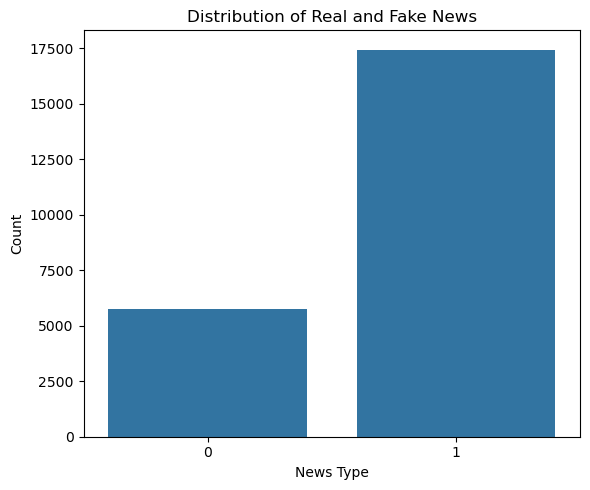

In [7]:
plt.figure(figsize=(6,5))
sns.countplot(x='real', data=Fake_df)
plt.xlabel('News Type')
plt.ylabel('Count')
plt.title('Distribution of Real and Fake News')
plt.tight_layout()
plt.show()

In [8]:
Fake_df=Fake_df.drop(columns=['news_url','source_domain', 'tweet_num'])
Fake_df.head()

,title,real
0,Kandi Burruss Explodes Over Rape Accusation on...,1
1,People's Choice Awards 2018: The best red carp...,1
2,Sophia Bush Sends Sweet Birthday Message to 'O...,1
3,Colombian singer Maluma sparks rumours of inap...,1
4,Gossip Girl 10 Years Later: How Upper East Sid...,1


In [9]:
Fake_df=Fake_df.drop_duplicates()
Fake_df.duplicated().sum()

np.int64(0)

In [10]:
def clean_text(text):
    text=text.lower()
    text=re.sub(r'http\S+', '', text)
    text=re.sub(r'[^a-z\s]', '', text)
    return text

Fake_df['clean_title']=Fake_df['title'].apply(clean_text)
Fake_df.head()

,title,real,clean_title
0,Kandi Burruss Explodes Over Rape Accusation on...,1,kandi burruss explodes over rape accusation on...
1,People's Choice Awards 2018: The best red carp...,1,peoples choice awards the best red carpet looks
2,Sophia Bush Sends Sweet Birthday Message to 'O...,1,sophia bush sends sweet birthday message to on...
3,Colombian singer Maluma sparks rumours of inap...,1,colombian singer maluma sparks rumours of inap...
4,Gossip Girl 10 Years Later: How Upper East Sid...,1,gossip girl years later how upper east siders...


In [11]:
X=Fake_df['clean_title']
y=Fake_df['real']
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set size,  X_train:{X_train.shape}, y_train:{y_train.shape}")
print(f"Testing set size, X_test: {X_test.shape}, y_test: {y_test.shape}")

Training set size,  X_train:(17477,), y_train:(17477,)
Testing set size, X_test: (4370,), y_test: (4370,)


In [12]:
tfidf=TfidfVectorizer(max_features=5000)
X_train_tfidf=tfidf.fit_transform(X_train)
X_test_tfidf=tfidf.transform(X_test)

In [13]:
LG=LogisticRegression(max_iter=1000, class_weight='balanced').fit(X_train_tfidf, y_train)
eval_train_lg=LG.predict(X_train_tfidf)
eval_test_lg=LG.predict(X_test_tfidf)

acc_lg=accuracy_score(y_test, eval_test_lg)
prec_lg=precision_score(y_test, eval_test_lg)
recall_lg=recall_score(y_test, eval_test_lg)
f1_lg=f1_score(y_test, eval_test_lg)
roc_auc_lg=roc_auc_score(y_test, eval_test_lg)

In [14]:
result_df=({
    "Accuracy":[acc_lg],
    "Precision":[prec_lg],
    "Recall":[recall_lg],
    "F1 Score":[f1_lg],
    "ROC AUC":[roc_auc_lg]
})
result_df=pd.DataFrame(result_df, index=['Logistic Regression'])
result_df.head()

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,0.798398,0.897377,0.828139,0.861369,0.767121


In [15]:
print('Training Data ')
print("Classification Report:\n", classification_report(y_train, eval_train_lg))
print('='*50)
print("Testing Data")
print("Classification Report:\n", classification_report(y_test, eval_test_lg))

Training Data 
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.85      0.75      4258
           1       0.95      0.87      0.91     13219

    accuracy                           0.86     17477
   macro avg       0.81      0.86      0.83     17477
weighted avg       0.88      0.86      0.87     17477

Testing Data
Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.71      0.63      1065
           1       0.90      0.83      0.86      3305

    accuracy                           0.80      4370
   macro avg       0.73      0.77      0.75      4370
weighted avg       0.82      0.80      0.81      4370



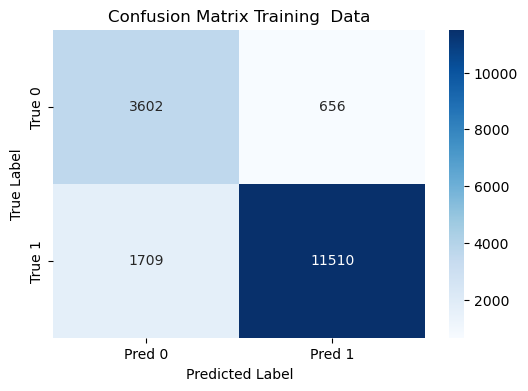

In [16]:
cm_train_lg=confusion_matrix(y_train, eval_train_lg)
plt.figure(figsize=(6,4))
sns.heatmap(cm_train_lg, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Training  Data')
plt.show()

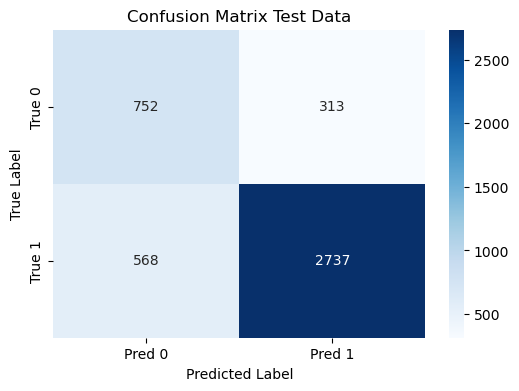

In [17]:
cm_test_lg=confusion_matrix(y_test, eval_test_lg)
plt.figure(figsize=(6,4))
sns.heatmap(cm_test_lg, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Test Data')
plt.show()

In [18]:
RF=RandomForestClassifier(class_weight='balanced', random_state=42).fit(X_train_tfidf, y_train)
eval_train_rf=RF.predict(X_train_tfidf)
eval_test_rf=RF.predict(X_test_tfidf)

acc_rf=accuracy_score(y_test, eval_test_rf)
prec_rf=precision_score(y_test, eval_test_rf)
recall_rf=recall_score(y_test, eval_test_rf)
f1_rf=f1_score(y_test, eval_test_rf)
roc_auc_rf=roc_auc_score(y_test, eval_test_rf)

In [19]:
result_df.loc['Random Forest']=[acc_rf, prec_rf, recall_rf, f1_rf, roc_auc_rf]
result_df.head()

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,0.798398,0.897377,0.828139,0.861369,0.767121
Random Forest,0.811670,0.840560,0.926778,0.881566,0.690619


In [20]:
print('Training Data')
print('Classification Report:\n', classification_report(y_train, eval_train_rf))
print('='*50)
print('Testing Data')
print('Classification Report:\n', classification_report(y_test, eval_test_rf))

Training Data
Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      4258
           1       1.00      0.99      1.00     13219

    accuracy                           0.99     17477
   macro avg       0.99      0.99      0.99     17477
weighted avg       0.99      0.99      0.99     17477

Testing Data
Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.45      0.54      1065
           1       0.84      0.93      0.88      3305

    accuracy                           0.81      4370
   macro avg       0.75      0.69      0.71      4370
weighted avg       0.80      0.81      0.80      4370



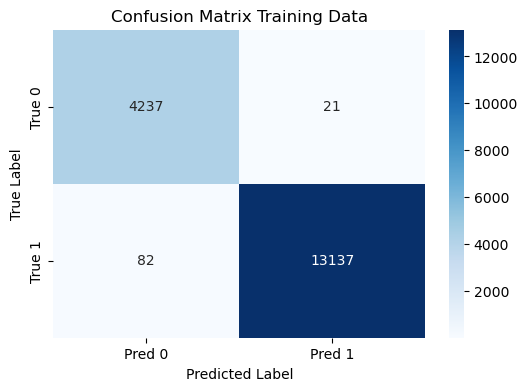

In [21]:
cm_train_rf=confusion_matrix(y_train, eval_train_rf)
plt.figure(figsize=(6,4 ))
sns.heatmap(cm_train_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Training Data')
plt.show()

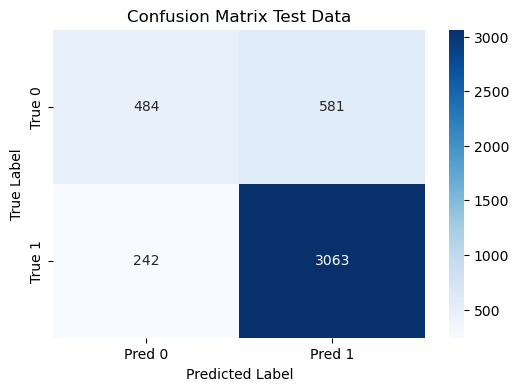

In [22]:
cm_test_rf=confusion_matrix(y_test, eval_test_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm_test_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred 0','Pred 1'], yticklabels=['True 0', 'True 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Test Data')
plt.show()

In [23]:
Dt=DecisionTreeClassifier(class_weight='balanced', random_state=42).fit(X_train_tfidf, y_train)
eval_train_dt=Dt.predict(X_train_tfidf)
eval_test_dt=Dt.predict(X_test_tfidf)

acc_dt=accuracy_score(y_test, eval_test_dt)
prec_dt=precision_score(y_test, eval_test_dt)
recall_dt=recall_score(y_test, eval_test_dt)
f1_dt=f1_score(y_test, eval_test_dt)
roc_auc_dt=roc_auc_score(y_test, eval_test_dt)

In [24]:
result_df.loc['Decision Tree']=[acc_dt, prec_dt, recall_dt, f1_dt, roc_auc_dt]
result_df.head()

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,0.798398,0.897377,0.828139,0.861369,0.767121
Random Forest,0.811670,0.840560,0.926778,0.881566,0.690619
Decision Tree,0.715789,0.844178,0.765507,0.802920,0.663505


In [25]:
print('Training Data')
print('Classification Report:\n', classification_report(y_train, eval_train_dt))
print('='*50)
print('Testing Data')
print('Classification Report:\n', classification_report(y_test, eval_test_dt))

Training Data
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99      4258
           1       1.00      0.99      1.00     13219

    accuracy                           0.99     17477
   macro avg       0.99      1.00      0.99     17477
weighted avg       0.99      0.99      0.99     17477

Testing Data
Classification Report:
               precision    recall  f1-score   support

           0       0.44      0.56      0.49      1065
           1       0.84      0.77      0.80      3305

    accuracy                           0.72      4370
   macro avg       0.64      0.66      0.65      4370
weighted avg       0.74      0.72      0.73      4370



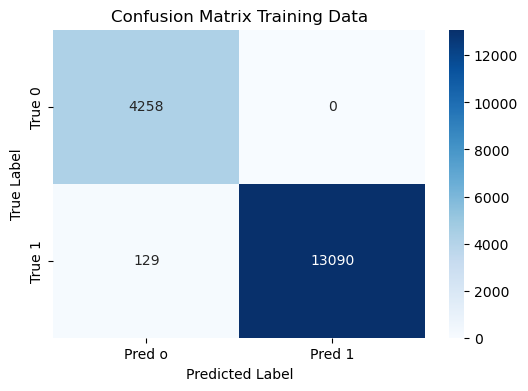

In [26]:
cm_train_dt=confusion_matrix(y_train, eval_train_dt)
plt.figure(figsize=(6,4))
sns.heatmap(cm_train_dt, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred o', 'Pred 1'], yticklabels=['True 0', 'True 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Training Data')
plt.show()

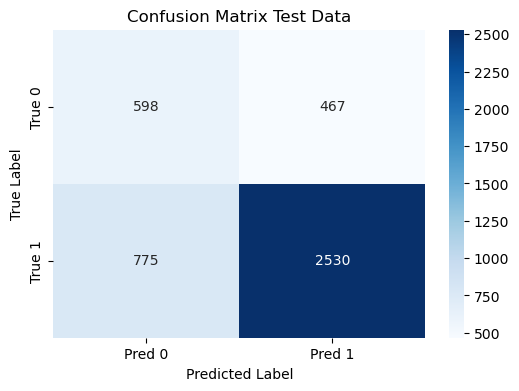

In [27]:
cm_test_dt=confusion_matrix(y_test, eval_test_dt)
plt.figure(figsize=(6,4))
sns.heatmap(cm_test_dt, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Test Data')
plt.show()

In [28]:
SVM=SVC(class_weight='balanced').fit(X_train_tfidf, y_train)
eval_train_svm=SVM.predict(X_train_tfidf)
eval_test_svm=SVM.predict(X_test_tfidf)

acc_svm=accuracy_score(y_test, eval_test_svm)
prec_svm=precision_score(y_test, eval_test_svm)
recall_svm=recall_score(y_test, eval_test_svm)
f1_svm=f1_score(y_test, eval_test_svm)
roc_auc_svm=roc_auc_score(y_test, eval_test_svm)

In [29]:
result_df.loc['SVM']=[acc_svm, prec_svm, recall_svm, f1_svm, roc_auc_svm]
result_df.head()

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,0.798398,0.897377,0.828139,0.861369,0.767121
Random Forest,0.811670,0.840560,0.926778,0.881566,0.690619
Decision Tree,0.715789,0.844178,0.765507,0.802920,0.663505
SVM,0.818535,0.874925,0.886838,0.880841,0.746705


In [30]:
print('Training Data')
print('Classification Report:\n', classification_report(y_train, eval_train_dt))
print('='*50)
print('Testing Data')
print('Classification Report:\n', classification_report(y_test, eval_test_dt))

Training Data
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99      4258
           1       1.00      0.99      1.00     13219

    accuracy                           0.99     17477
   macro avg       0.99      1.00      0.99     17477
weighted avg       0.99      0.99      0.99     17477

Testing Data
Classification Report:
               precision    recall  f1-score   support

           0       0.44      0.56      0.49      1065
           1       0.84      0.77      0.80      3305

    accuracy                           0.72      4370
   macro avg       0.64      0.66      0.65      4370
weighted avg       0.74      0.72      0.73      4370



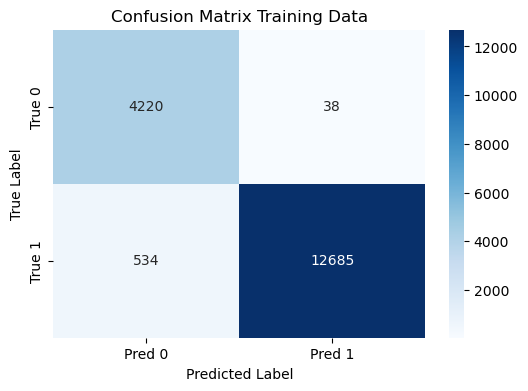

In [31]:
cm_train_svm=confusion_matrix(y_train, eval_train_svm)
plt.figure(figsize=(6,4))
sns.heatmap(cm_train_svm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Training Data')
plt.show()

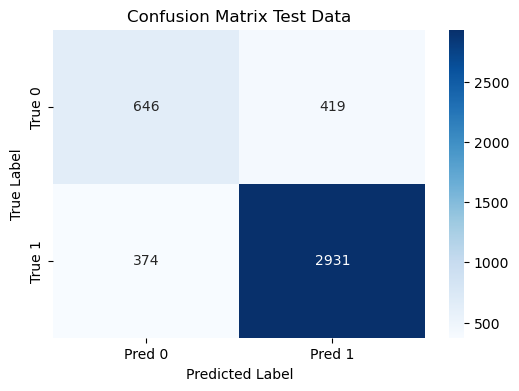

In [32]:
cm_test_svm=confusion_matrix(y_test, eval_test_svm)
plt.figure(figsize=(6,4))
sns.heatmap(cm_test_svm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Test Data')
plt.show()